In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage,dendrogram,fcluster
from sklearn.metrics import silhouette_score

# 1.

In [2]:
df = pd.read_csv("/home/sav/Desktop/Machine_Learning/Assignments/Datasets/EastWest .csv")
df.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


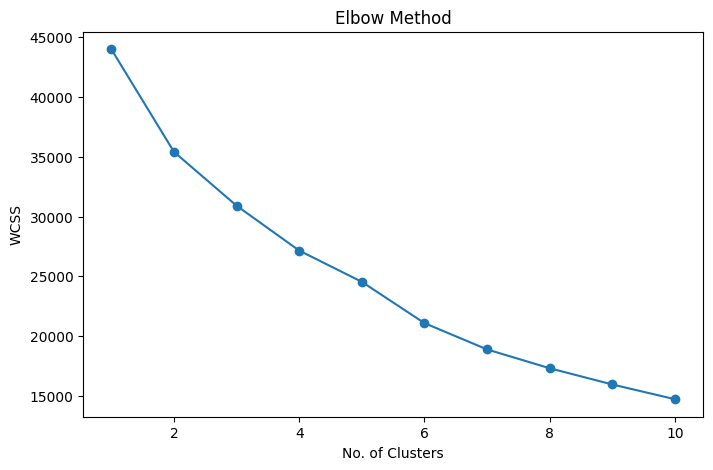

In [3]:
df = df.drop(columns=['ID#'], errors='ignore')

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i,
                    random_state=42,
                    n_init=10)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11),wcss,marker='o')
plt.xlabel("No. of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [4]:
for k in range(2,11):
    model = KMeans(n_clusters=k,
                   random_state=42,
                   n_init=10)

    labels = model.fit_predict(scaled_data)

    score = silhouette_score(
        scaled_data,
        labels
    )

    print("Clusters =",k,
          "Silhouette Score =",round(score,3))

Clusters = 2 Silhouette Score = 0.325
Clusters = 3 Silhouette Score = 0.311
Clusters = 4 Silhouette Score = 0.309
Clusters = 5 Silhouette Score = 0.319
Clusters = 6 Silhouette Score = 0.333
Clusters = 7 Silhouette Score = 0.284
Clusters = 8 Silhouette Score = 0.237
Clusters = 9 Silhouette Score = 0.246
Clusters = 10 Silhouette Score = 0.262


In [5]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df['KMeans_Cluster'] = kmeans.fit_predict(scaled_data)

print(df['KMeans_Cluster'].value_counts())

KMeans_Cluster
1    2543
2    1273
3     168
0      15
Name: count, dtype: int64


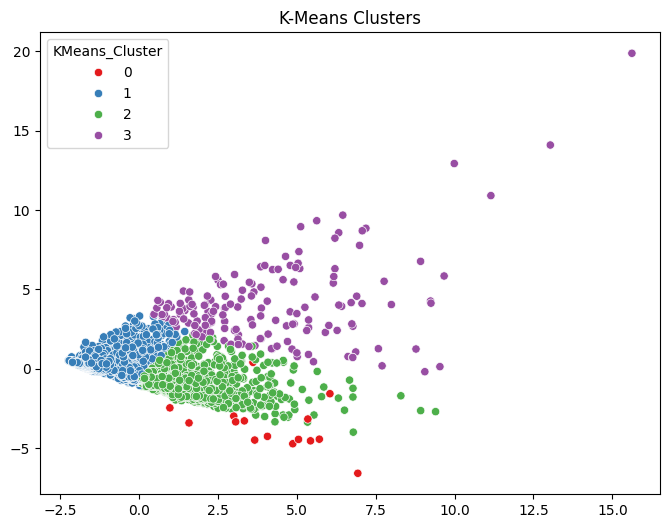

In [6]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled_data)

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=pca_data[:,0],
    y=pca_data[:,1],
    hue=df['KMeans_Cluster'],
    palette='Set1'
)

plt.title("K-Means Clusters")
plt.show()

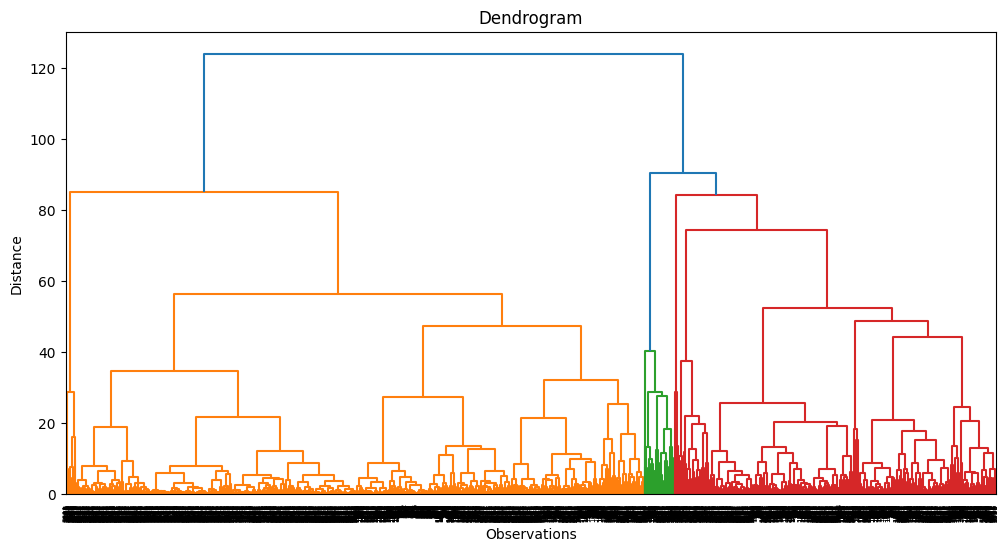

In [7]:
plt.figure(figsize=(12,6))

dendrogram(
    linkage(scaled_data,
            method='ward')
)

plt.title("Dendrogram")
plt.xlabel("Observations")
plt.ylabel("Distance")
plt.show()

In [8]:
hc_labels = fcluster(
    linkage(scaled_data,
            method='ward'),
    4,
    criterion='maxclust'
)

df['HC_Cluster'] = hc_labels

print(df['HC_Cluster'].value_counts())

HC_Cluster
2    2446
4    1380
3     130
1      43
Name: count, dtype: int64


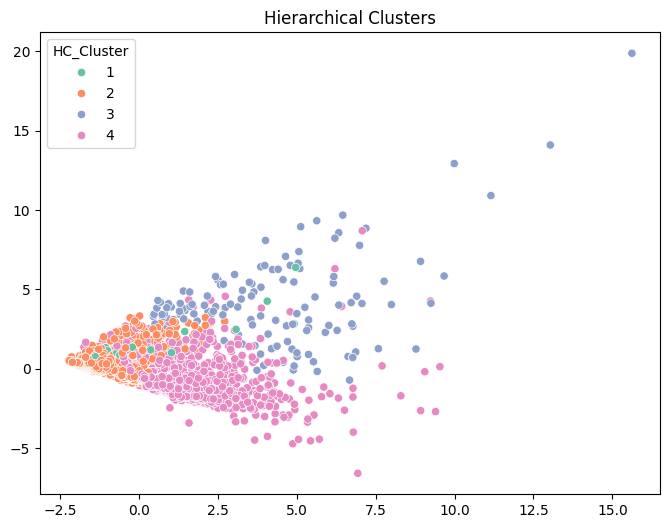

In [9]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=pca_data[:,0],
    y=pca_data[:,1],
    hue=df['HC_Cluster'],
    palette='Set2'
)

plt.title("Hierarchical Clusters")
plt.show()

# 2.

In [10]:
df = pd.read_csv("/home/sav/Desktop/Machine_Learning/Assignments/Datasets/crime_data.csv")
state_names = df.iloc[:,0]
df_num = df.iloc[:,1:]
df_num.head()

,Murder,Assault,UrbanPop,Rape
0,13.2,236,58,21.2
1,10.0,263,48,44.5
2,8.1,294,80,31.0
3,8.8,190,50,19.5
4,9.0,276,91,40.6


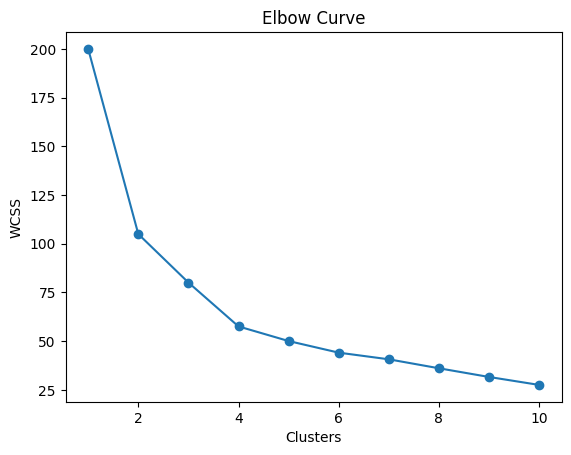

In [11]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_num)

wcss = []

for i in range(1,11):
    model = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    model.fit(scaled_data)

    wcss.append(model.inertia_)

plt.plot(range(1,11),wcss,marker='o')
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Curve")
plt.show()

In [12]:
for k in range(2,11):

    labels = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    ).fit_predict(scaled_data)

    score = silhouette_score(
        scaled_data,
        labels
    )

    print(k,round(score,3))

2 0.408
3 0.308
4 0.34
5 0.301
6 0.294
7 0.274
8 0.236
9 0.258
10 0.254


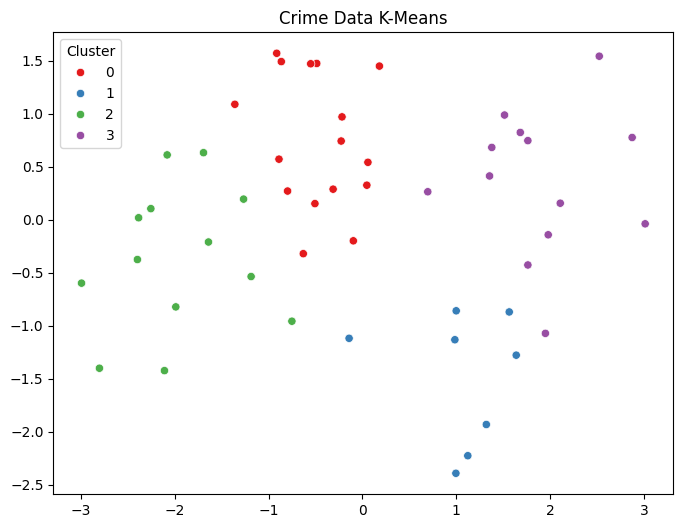

In [13]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df['Cluster'] = kmeans.fit_predict(
    scaled_data
)

from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_data = pca.fit_transform(
    scaled_data
)

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=pca_data[:,0],
    y=pca_data[:,1],
    hue=df['Cluster'],
    palette='Set1'
)

plt.title("Crime Data K-Means")
plt.show()

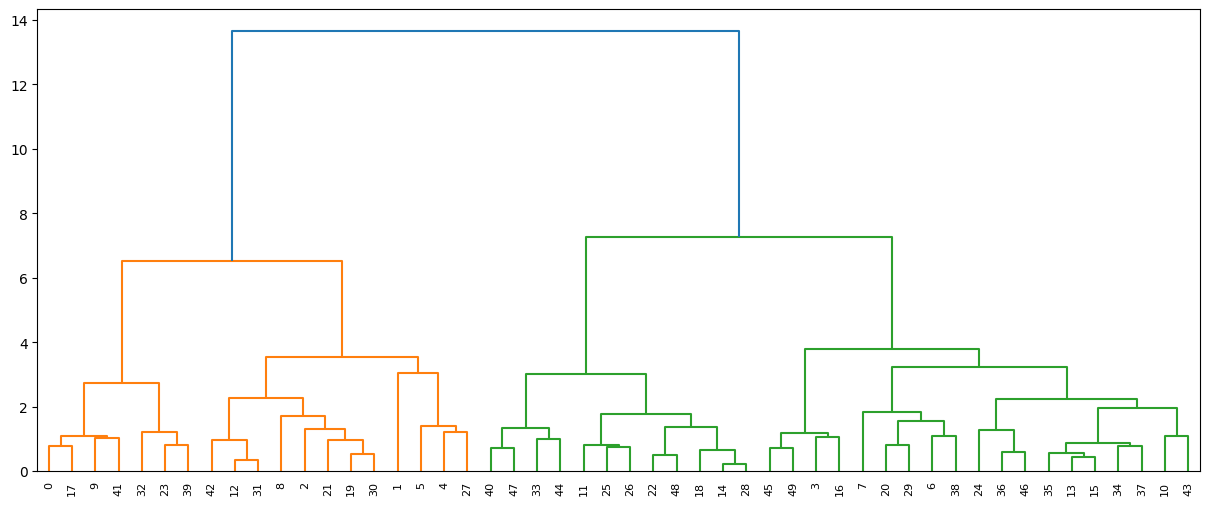

In [14]:
plt.figure(figsize=(15,6))

dendrogram(
    linkage(
        scaled_data,
        method='ward'
    )
)

plt.show()

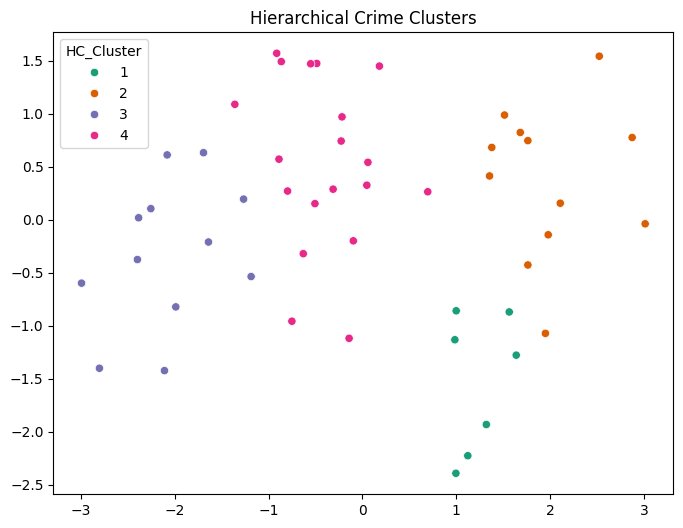

In [15]:
hc_labels = fcluster(
    linkage(
        scaled_data,
        method='ward'
    ),
    4,
    criterion='maxclust'
)

df['HC_Cluster'] = hc_labels

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=pca_data[:,0],
    y=pca_data[:,1],
    hue=df['HC_Cluster'],
    palette='Dark2'
)

plt.title(
    "Hierarchical Crime Clusters"
)

plt.show()

# 3.

In [16]:
df = pd.read_csv("/home/sav/Desktop/Machine_Learning/Assignments/Datasets/Universities.csv")

df.head()

,Univ,SAT,Top10,Accept,SFRatio,Expenses,GradRate
0,Brown,1310,89,22,13,22704,94
1,CalTech,1415,100,25,6,63575,81
2,CMU,1260,62,59,9,25026,72
3,Columbia,1310,76,24,12,31510,88
4,Cornell,1280,83,33,13,21864,90


In [17]:
university_names = df.iloc[:,0]
df_num = df.iloc[:,1:]

scaler = StandardScaler()
scaled_data = scaler.fit_transform(
    df_num
)

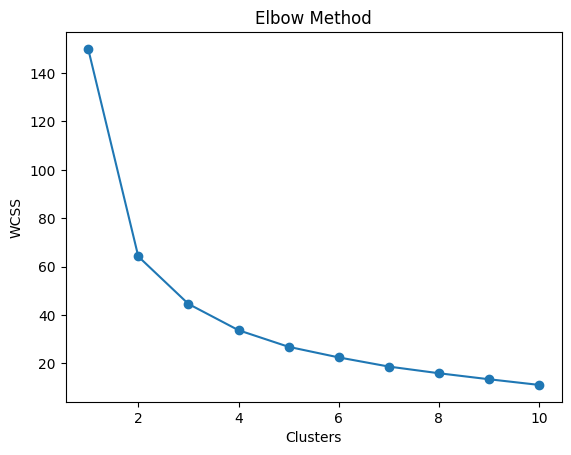

In [18]:
wcss = []

for i in range(1,11):

    model = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    model.fit(scaled_data)

    wcss.append(
        model.inertia_
    )

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [19]:
for k in range(2,11):

    labels = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    ).fit_predict(
        scaled_data
    )

    score = silhouette_score(
        scaled_data,
        labels
    )

    print(
        "Cluster",
        k,
        "Score",
        round(score,3)
    )

Cluster 2 Score 0.54
Cluster 3 Score 0.322
Cluster 4 Score 0.33
Cluster 5 Score 0.305
Cluster 6 Score 0.298
Cluster 7 Score 0.279
Cluster 8 Score 0.271
Cluster 9 Score 0.263
Cluster 10 Score 0.228


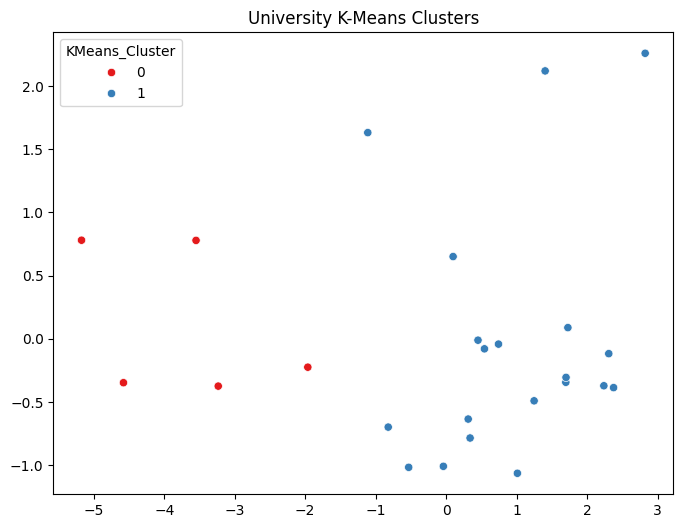

In [20]:
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

df['KMeans_Cluster'] = kmeans.fit_predict(
    scaled_data
)

pca = PCA(
    n_components=2
)

pca_data = pca.fit_transform(
    scaled_data
)

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=pca_data[:,0],
    y=pca_data[:,1],
    hue=df['KMeans_Cluster'],
    palette='Set1'
)

plt.title(
    "University K-Means Clusters"
)

plt.show()

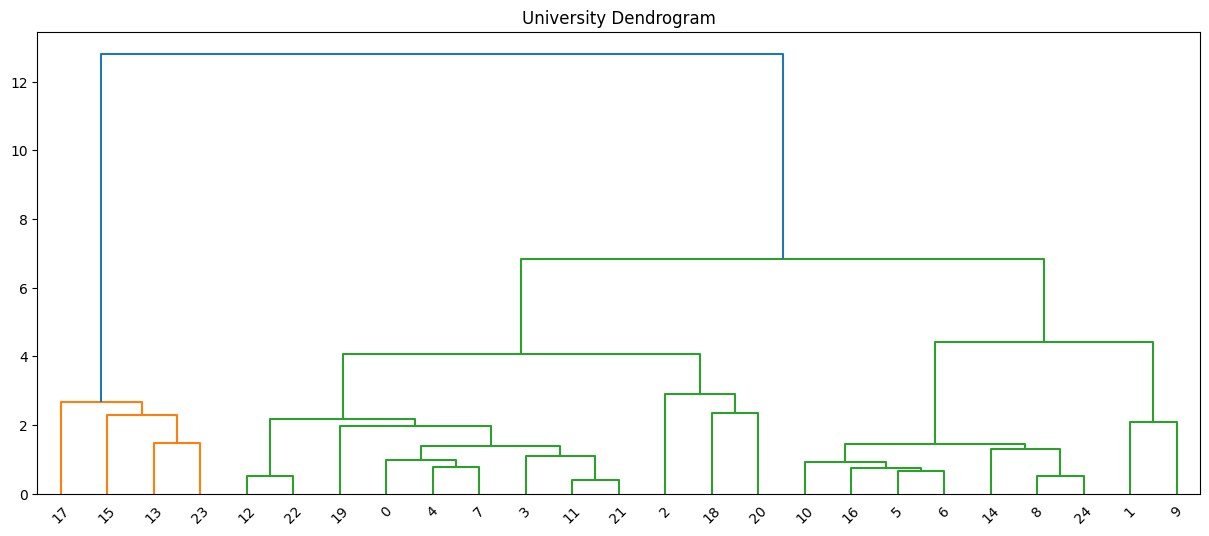

In [21]:
plt.figure(figsize=(15,6))

dendrogram(
    linkage(
        scaled_data,
        method='ward'
    )
)

plt.title(
    "University Dendrogram"
)

plt.show()

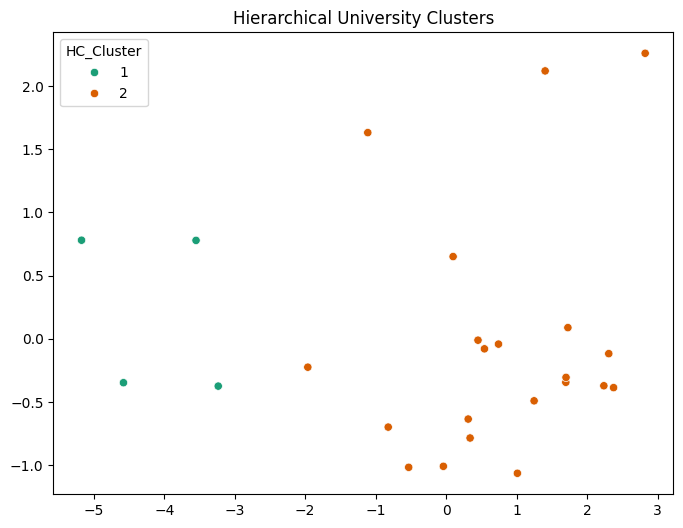

In [22]:
hc_labels = fcluster(
    linkage(
        scaled_data,
        method='ward'
    ),
    2,
    criterion='maxclust'
)

df['HC_Cluster'] = hc_labels

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=pca_data[:,0],
    y=pca_data[:,1],
    hue=df['HC_Cluster'],
    palette='Dark2'
)

plt.title(
    "Hierarchical University Clusters"
)

plt.show()